<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/Hypoxia18hrs_Accessibility_vs_Expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/your/path/'  #change dir to your project folder

Mounted at /content/drive/


In [ ]:
pip install matplotlib-venn

In [ ]:
import pandas as pd
import numpy as np
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

In [ ]:
allhypox = pd.read_csv("/your/path/Hypoxia_18hrsVsNormoxiaDGEGenesAll.csv") # which is long hypox


In [ ]:
atac = pd.read_csv('/your/path/Hyp18vs8hpf_ATAC_NewParam.csv')

In [ ]:
atac

,names,seqnames,starts,ends,scores,strand,width,Conc,Conc_Anoxia_18hrs,Conc_x8hpf,Fold,p.value,FDR,gene_name
0,peak_100005,chr4,4324264,4324665,0,.,401,6.506871,6.986408,5.783553,1.045443,0.000580,0.003305,NaN
1,peak_100006,chr4,4332824,4333225,0,.,401,4.517402,3.604654,5.072067,-1.000136,0.011579,0.037222,NaN
2,peak_100014,chr4,4435304,4435705,0,.,401,4.587645,3.605108,5.166739,-1.152293,0.003769,0.015184,ntf3
3,peak_100017,chr4,4466387,4466788,0,.,401,7.576592,6.718963,8.110794,-1.230124,0.000025,0.000237,tbc1d30
4,peak_100018,chr4,4479884,4480285,0,.,401,5.329944,5.914643,4.330736,1.246689,0.000643,0.003602,tbc1d30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47227,peak_99985,chr4,4207019,4207420,0,.,401,5.343971,5.863600,4.523899,0.912834,0.016329,0.048934,LOC110439412
47228,peak_99986,chr4,4207895,4208296,0,.,401,6.189058,5.041592,6.820006,-1.553567,0.000006,0.000068,LOC110439412
47229,peak_99995,chr4,4232350,4232751,0,.,401,6.853459,7.372776,6.034177,1.188008,0.000024,0.000229,smkr1
47230,peak_99996,chr4,4233572,4233973,0,.,401,5.294071,5.951685,4.051190,1.402156,0.000565,0.003235,smkr1


In [ ]:
allatac = atac.copy()

In [ ]:
allatac

,names,seqnames,starts,ends,scores,strand,width,Conc,Conc_Anoxia_18hrs,Conc_x8hpf,Fold,p.value,FDR,gene_name
0,peak_100005,chr4,4324264,4324665,0,.,401,6.506871,6.986408,5.783553,1.045443,0.000580,0.003305,NaN
1,peak_100006,chr4,4332824,4333225,0,.,401,4.517402,3.604654,5.072067,-1.000136,0.011579,0.037222,NaN
2,peak_100014,chr4,4435304,4435705,0,.,401,4.587645,3.605108,5.166739,-1.152293,0.003769,0.015184,ntf3
3,peak_100017,chr4,4466387,4466788,0,.,401,7.576592,6.718963,8.110794,-1.230124,0.000025,0.000237,tbc1d30
4,peak_100018,chr4,4479884,4480285,0,.,401,5.329944,5.914643,4.330736,1.246689,0.000643,0.003602,tbc1d30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47227,peak_99985,chr4,4207019,4207420,0,.,401,5.343971,5.863600,4.523899,0.912834,0.016329,0.048934,LOC110439412
47228,peak_99986,chr4,4207895,4208296,0,.,401,6.189058,5.041592,6.820006,-1.553567,0.000006,0.000068,LOC110439412
47229,peak_99995,chr4,4232350,4232751,0,.,401,6.853459,7.372776,6.034177,1.188008,0.000024,0.000229,smkr1
47230,peak_99996,chr4,4233572,4233973,0,.,401,5.294071,5.951685,4.051190,1.402156,0.000565,0.003235,smkr1


In [ ]:
# Filter the DataFrame
Upatac = allatac[(allatac['Fold'] > 1) & (allatac['FDR'] < 0.01)]

# Get the list of gene
UpatacList = Upatac['gene_name'].unique().tolist()
UpatacList = set(UpatacList)
# Filter the DataFrame
Downatac = allatac[(allatac['Fold'] < -1) & (allatac['FDR'] < 0.01)]

# Get the list of gene
DownatacList = Downatac['gene_name'].unique().tolist()
DownatacList = set(DownatacList)

In [ ]:
# Filter the DataFrame
Uphypox = allhypox[(allhypox['log2FoldChange'] > 1) & (allhypox['padj'] < 0.01)]

# Get the list of gene
UphypoxList = Uphypox['genes'].tolist()


# Filter the DataFrame
Downhypox = allhypox[(allhypox['log2FoldChange'] < -1) & (allhypox['padj'] < 0.01)]

# Get the list of gene
DownhypoxList = Downhypox['genes'].tolist()



UphypoxSet = set(UphypoxList)
DownhypoxSet = set(DownhypoxList)

/usr/local/lib/python3.12/dist-packages/matplotlib_venn/_venn2.py:162: UserWarning: normalize_to is deprecated. Please use layout_algorithm=matplotlib_venn.layout.venn2.DefaultLayoutAlgorithm(normalize_to) instead.
  warnings.warn(


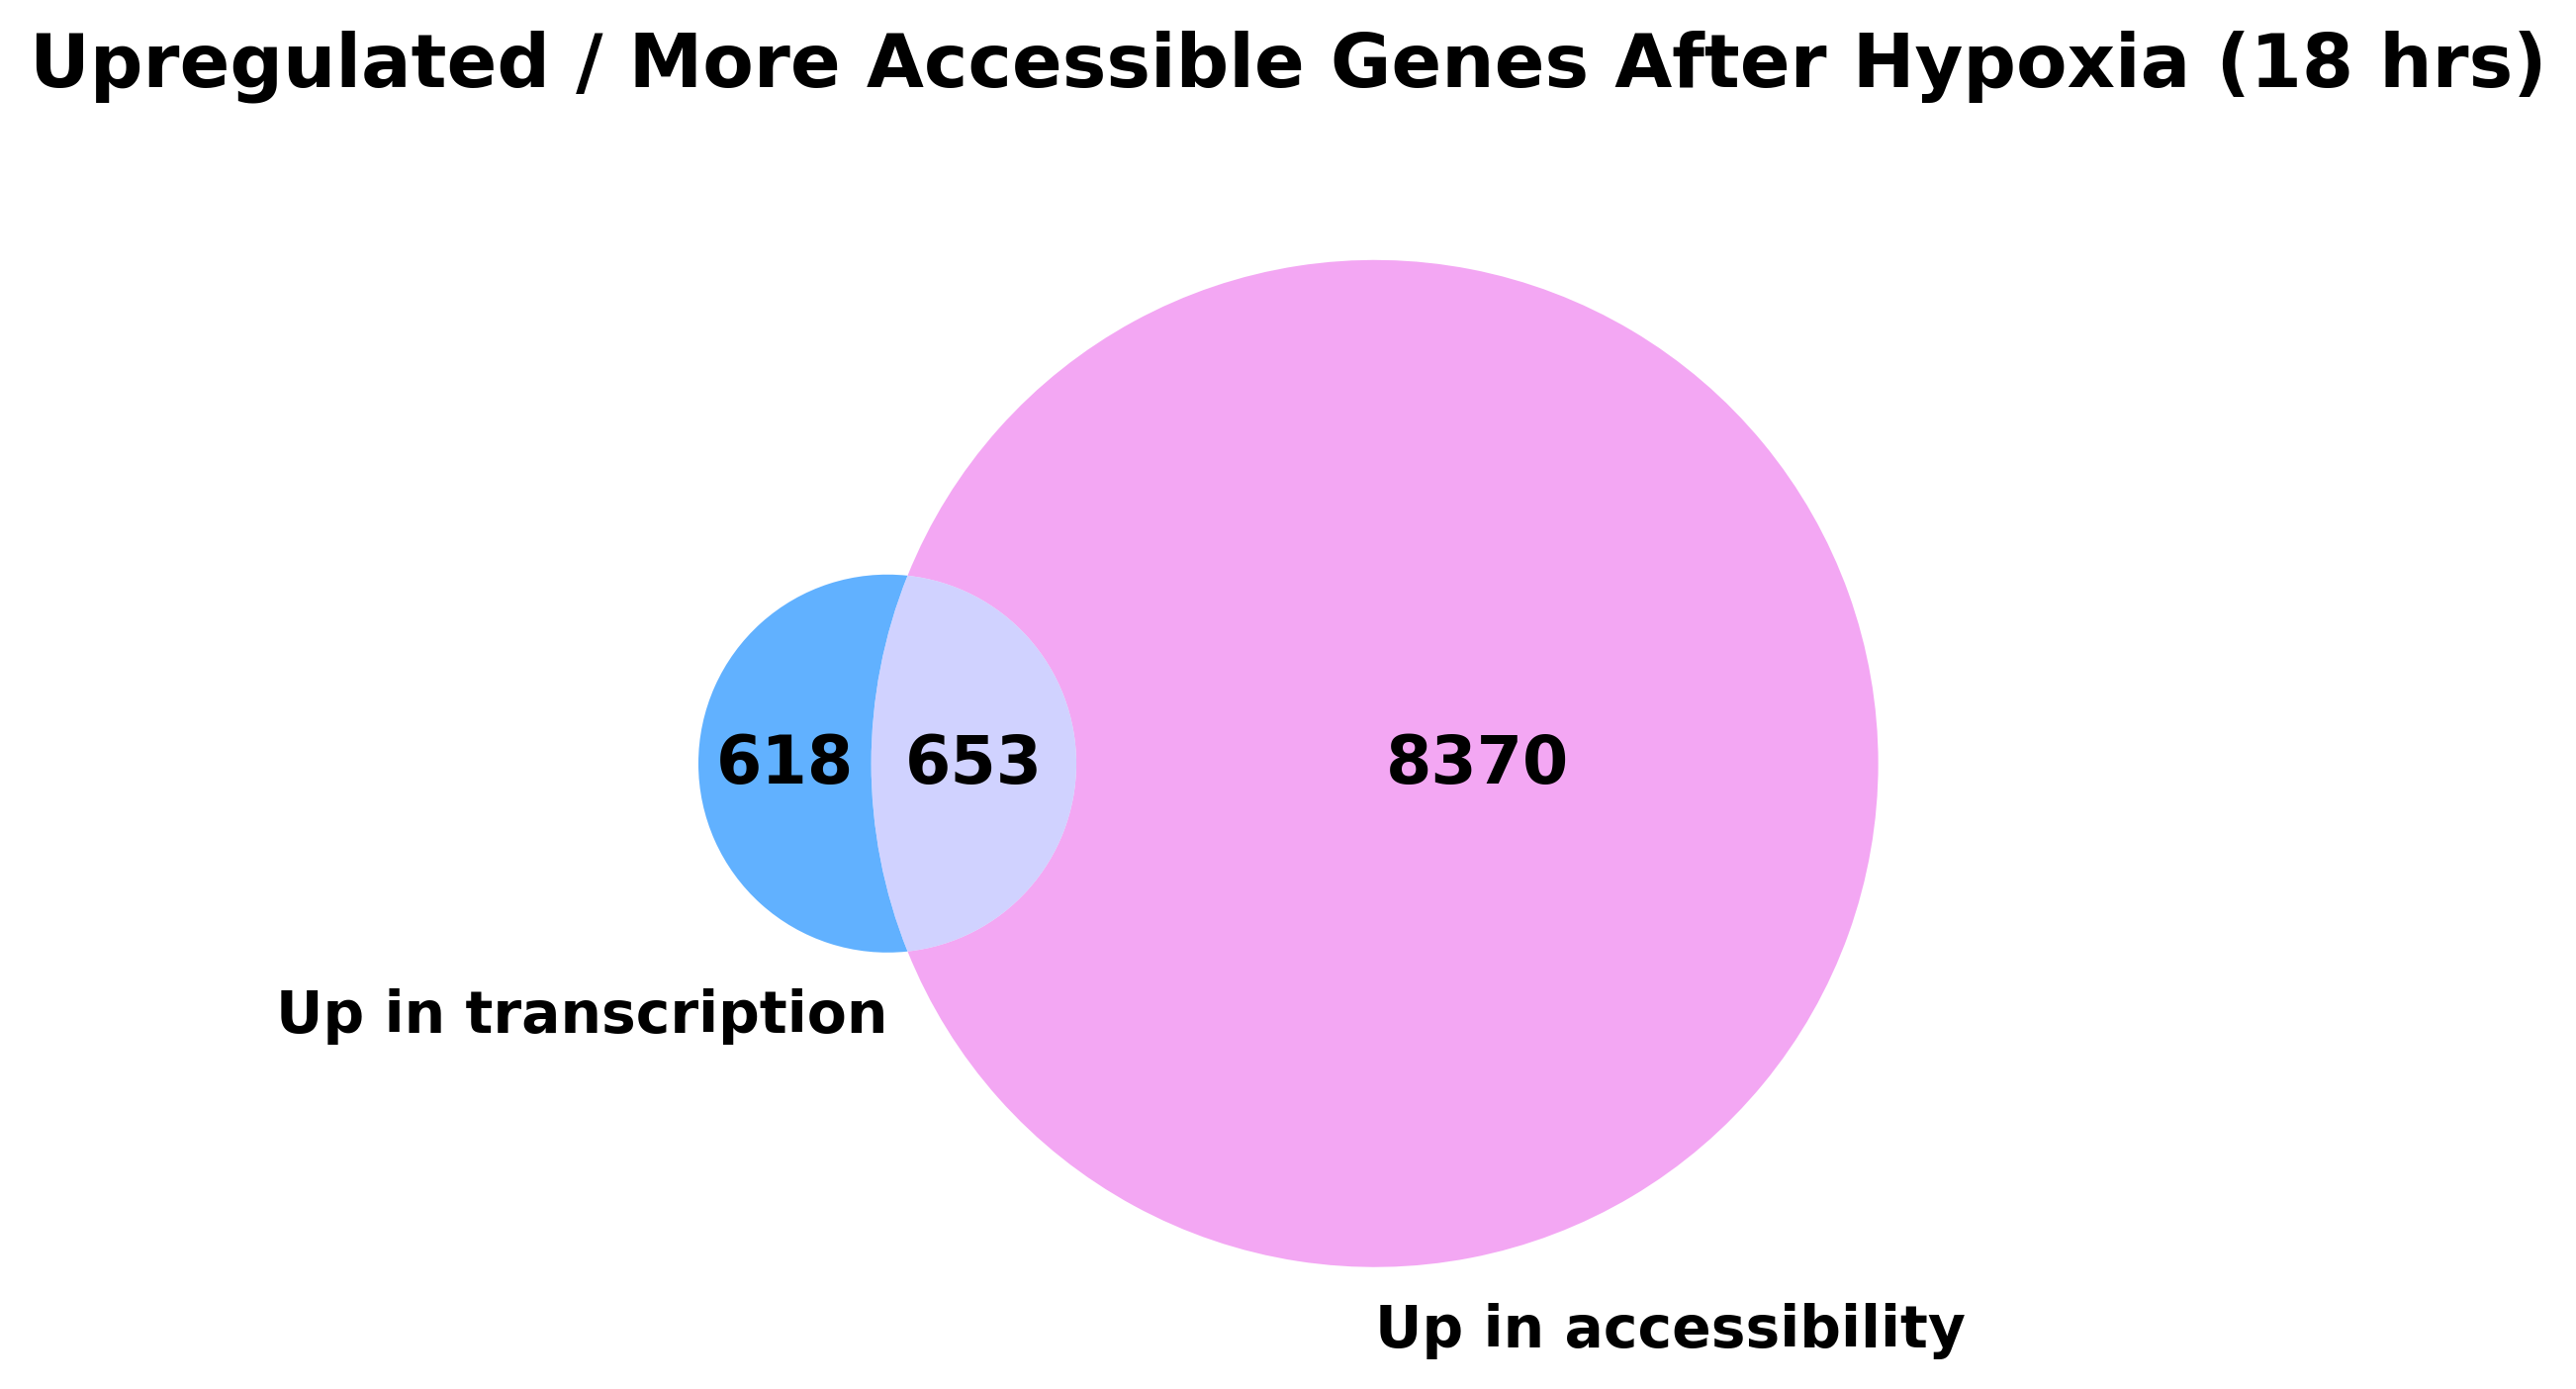

In [ ]:

# Create the figure
plt.figure(figsize=(6,6), dpi=300)

# Draw the Venn
venn = venn2(
    [UphypoxSet, UpatacList],
    set_labels=('Up in transcription', 'Up in accessibility'),
    set_colors=('dodgerblue', 'violet'),
    alpha=0.7,
    normalize_to=1.0
)

# Customize text sizes
for text in venn.set_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('bold')

for text in venn.subset_labels:
    if text:
        text.set_fontsize(16)
        text.set_fontweight('bold')

# Add a title
plt.title("Upregulated / More Accessible Genes After Hypoxia (18 hrs)",
          fontsize=18, fontweight='bold', pad=20)

# Optional: remove the axes frame for a cleaner look
plt.axis('off')

plt.tight_layout()
plt.show()


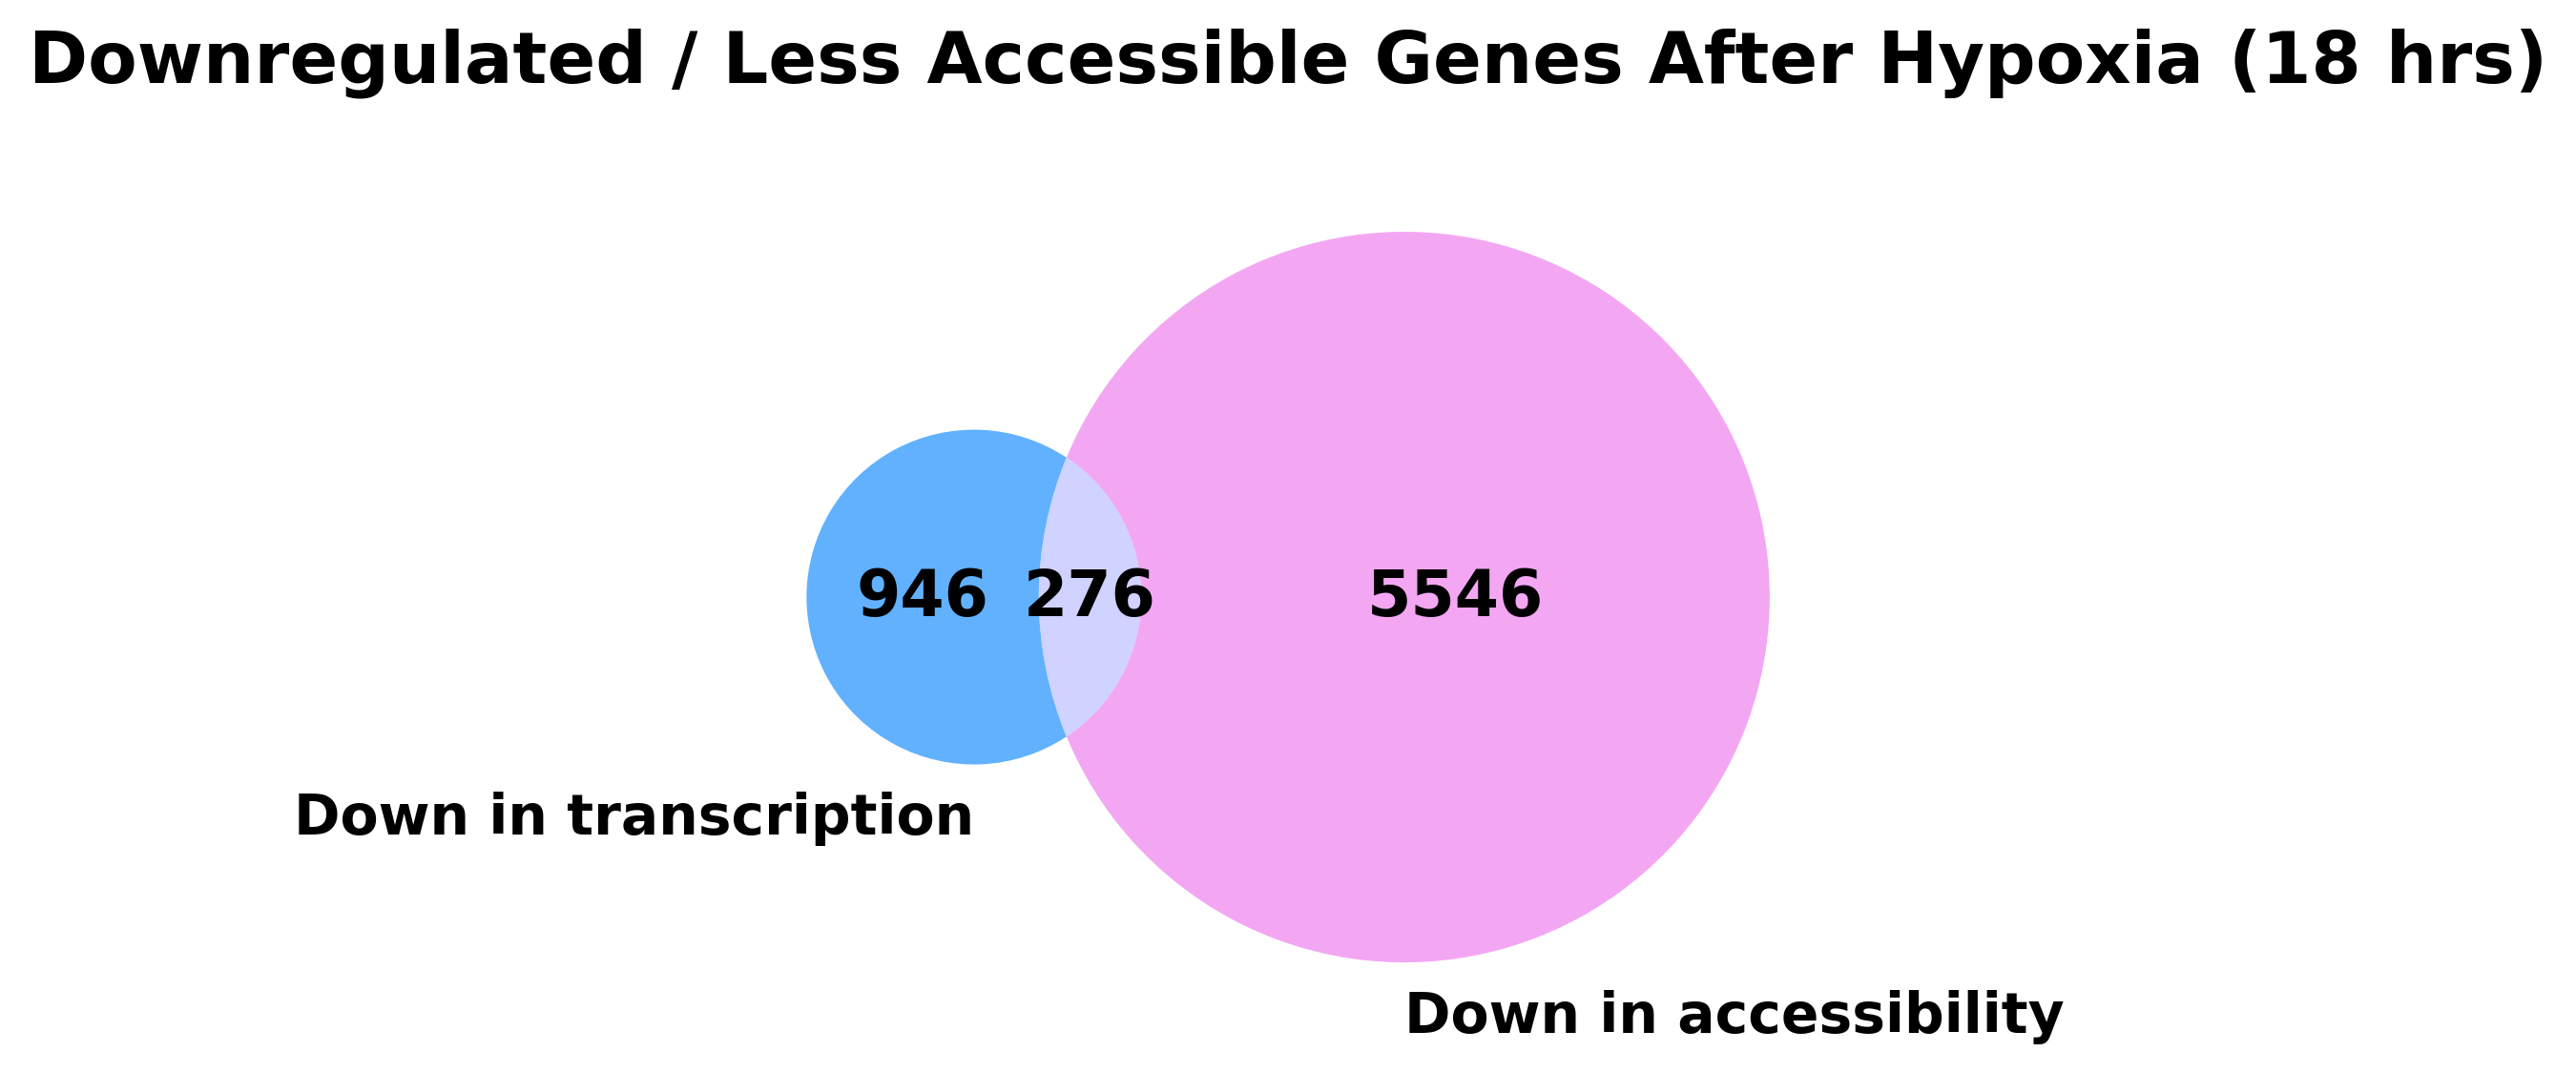

In [ ]:


# Create the figure
plt.figure(figsize=(6,6), dpi=300)

# Draw the Venn
venn = venn2(
    [DownhypoxSet, DownatacList],
    set_labels=('Down in transcription', 'Down in accessibility'),
    set_colors=('dodgerblue', 'violet'),
    alpha=0.7,
    normalize_to=1.0
)

# Customize text sizes
for text in venn.set_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('bold')

for text in venn.subset_labels:
    if text:
        text.set_fontsize(16)
        text.set_fontweight('bold')

# Add a title
plt.title("Downregulated / Less Accessible Genes After Hypoxia (18 hrs)",
          fontsize=18, fontweight='bold', pad=20)

# Optional: remove the axes frame for a cleaner look
plt.axis('off')

plt.tight_layout()
plt.show()
